In [1]:
import os
for dirname, _, filenames in os.walk('../data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


../data/mexico-city-real-estate-3.csv
../data/mexico-city-real-estate-2.csv
../data/mexico-city-real-estate-1.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score


# **Explotary Data analysis (EDA)**

In [3]:
df = pd.read_csv("../data/mexico-city-real-estate-1.csv")
df.head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,NaN,54.0,NaN,101851.851852,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/o3zb...
1,sell,house,|Iztapalapa|Distrito Federal|México|,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,NaN,80.0,NaN,18900.000000,NaN,NaN,NaN,http://iztapalapa.properati.com.mx/q7t0_venta_...
2,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,NaN,100.0,NaN,9266.670000,NaN,NaN,NaN,http://tlalpan.properati.com.mx/qbi4_venta_dep...
3,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,NaN,135.0,NaN,47481.481481,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/opeq...
4,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1902642,-86.8198375",875000.0,USD,16457437.50,875000.00,0.0,263.0,NaN,3326.996198,NaN,NaN,NaN,http://cancun.properati.com.mx/hg4t_venta_depa...


In [4]:
df.shape

(4628, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4628 entries, 0 to 4627
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   4628 non-null   str    
 1   property_type               4628 non-null   str    
 2   place_with_parent_names     4628 non-null   str    
 3   lat-lon                     4144 non-null   str    
 4   price                       4538 non-null   float64
 5   currency                    4538 non-null   str    
 6   price_aprox_local_currency  4538 non-null   float64
 7   price_aprox_usd             4538 non-null   float64
 8   surface_total_in_m2         1668 non-null   float64
 9   surface_covered_in_m2       4436 non-null   float64
 10  price_usd_per_m2            1150 non-null   float64
 11  price_per_m2                4249 non-null   float64
 12  floor                       291 non-null    float64
 13  rooms                       136 non-null    

# **Checking for skewness of Numerics Data**

In [6]:
numeric_cols = df.select_dtypes("number").columns
numeric_cols

Index(['price', 'price_aprox_local_currency', 'price_aprox_usd',
       'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2',
       'price_per_m2', 'floor', 'rooms', 'expenses'],
      dtype='str')

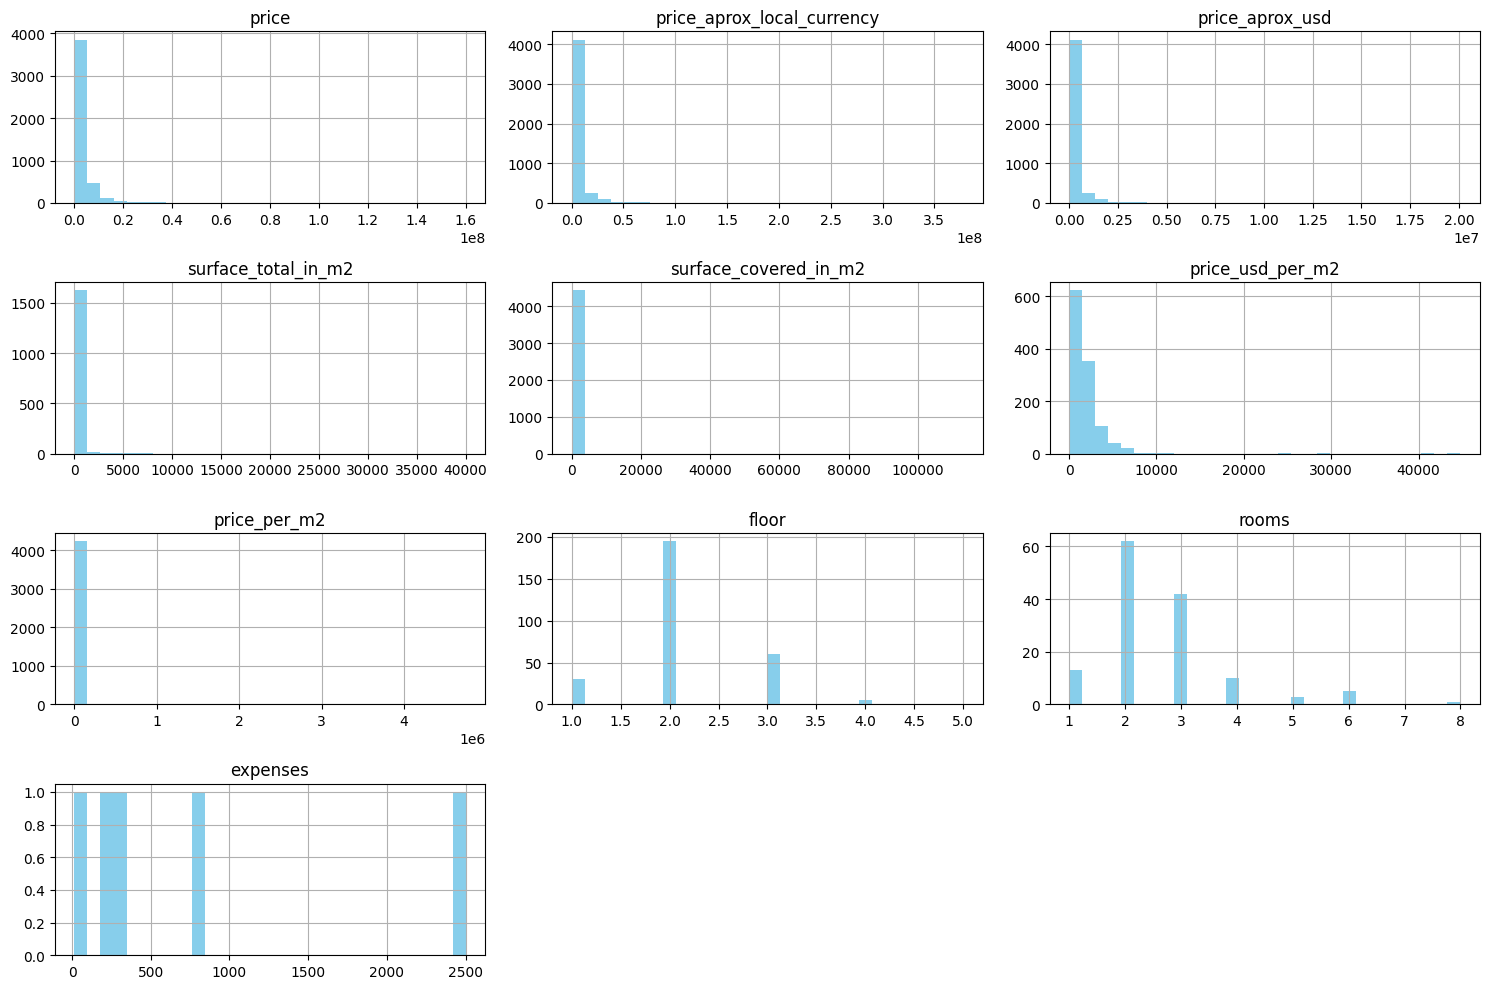

In [7]:
# Plot histograms for all numeric columns
df[numeric_cols].hist(bins=30, figsize=(15,10), color='skyblue')
plt.tight_layout()
plt.show()


# **Checking For Outliers in the data**

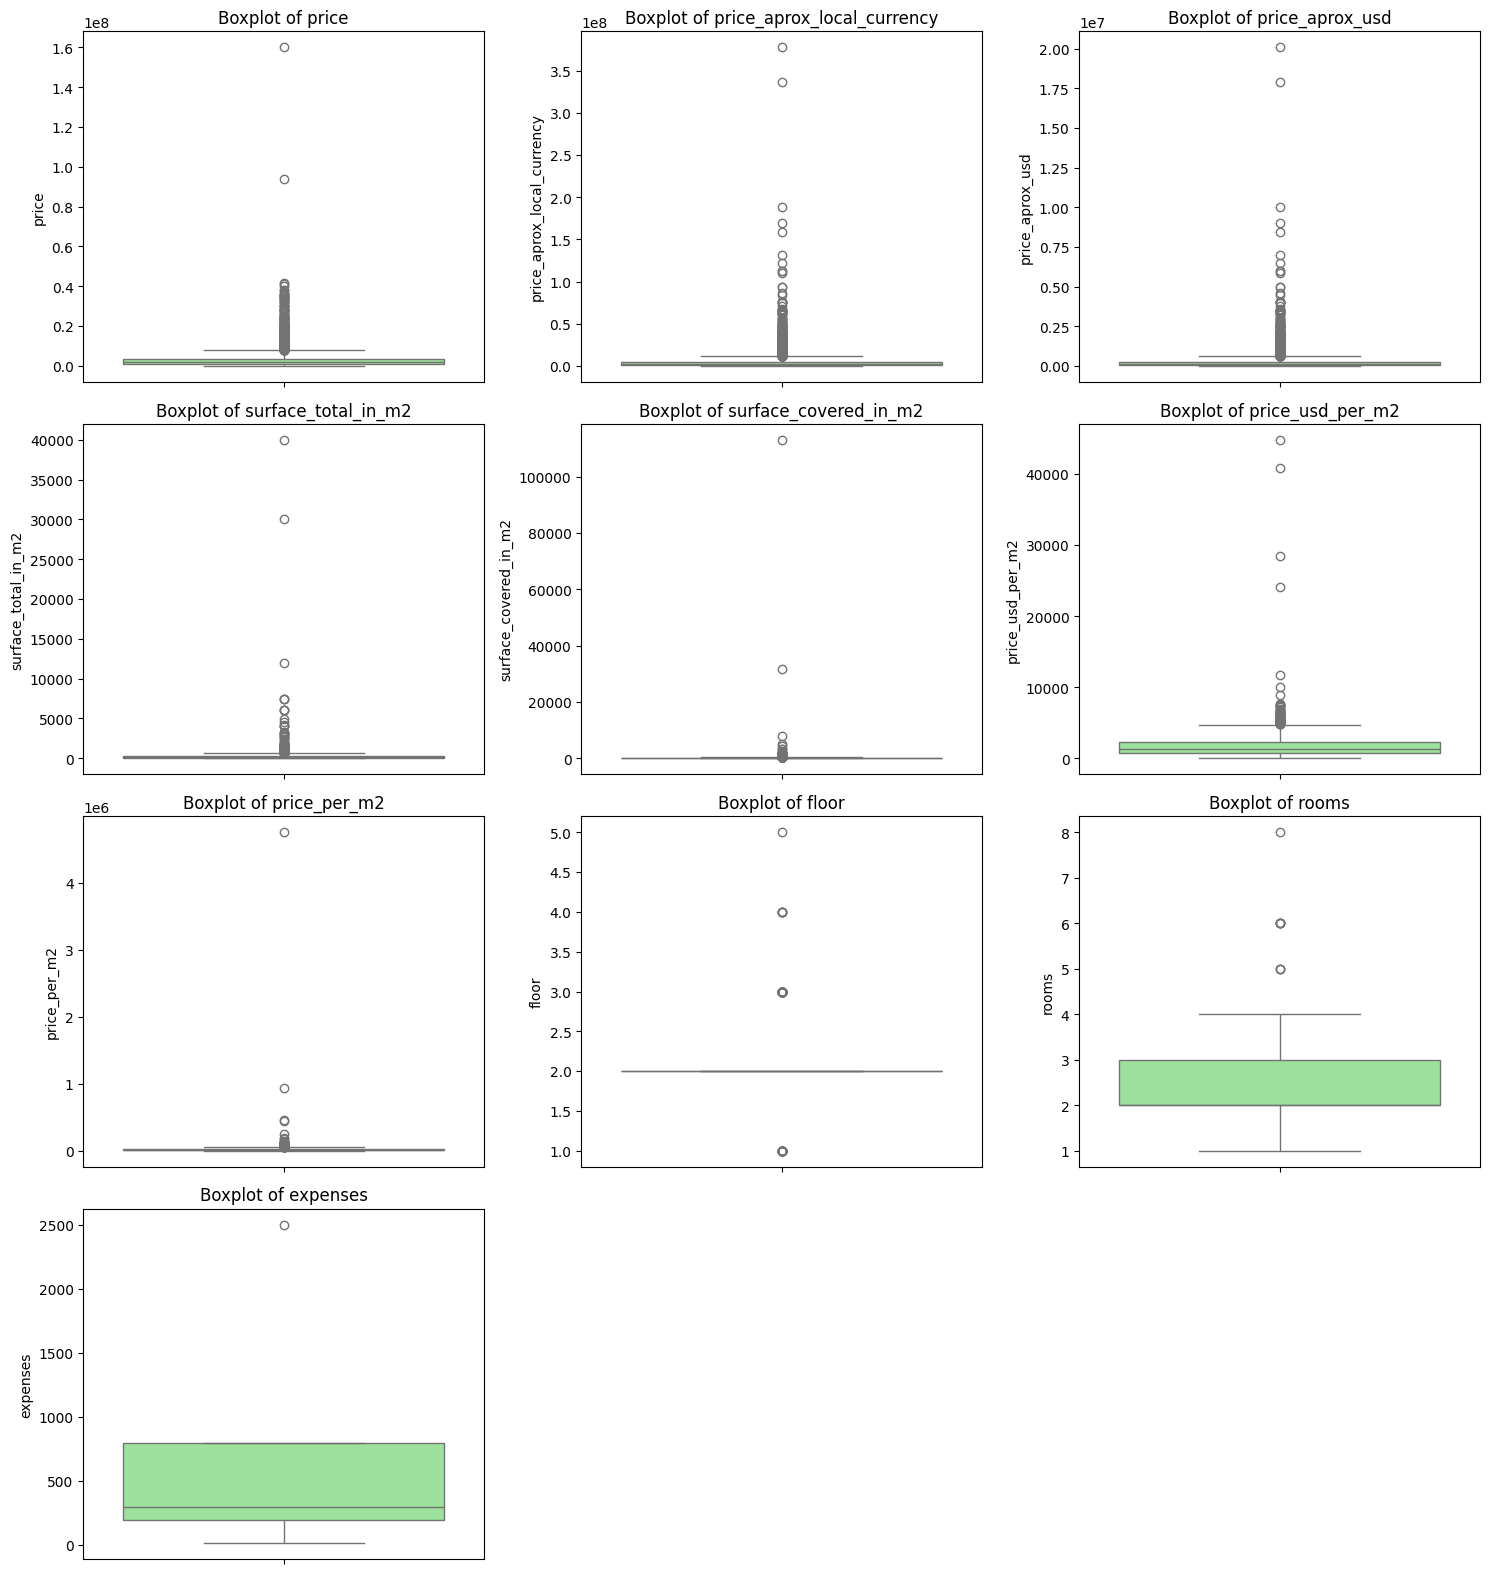

In [8]:
n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols)  # ceil division

plt.figure(figsize=(15, 4*n_rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [9]:
for col in numeric_cols:
    print(df[col].describe())
    print()


count    4.538000e+03
mean     3.244360e+06
std      5.055502e+06
min      3.700000e+04
25%      9.200000e+05
50%      1.846666e+06
75%      3.700000e+06
max      1.600000e+08
Name: price, dtype: float64

count    4.538000e+03
mean     5.584709e+06
std      1.257514e+07
min      1.238692e+05
25%      1.189215e+06
50%      2.527531e+06
75%      5.263110e+06
max      3.776868e+08
Name: price_aprox_local_currency, dtype: float64

count    4.538000e+03
mean     2.969247e+05
std      6.685879e+05
min      6.585810e+03
25%      6.322753e+04
50%      1.343824e+05
75%      2.798261e+05
max      2.008064e+07
Name: price_aprox_usd, dtype: float64

count     1668.000000
mean       287.982614
std       1374.944319
min          0.000000
25%          0.000000
50%        109.500000
75%        244.250000
max      40000.000000
Name: surface_total_in_m2, dtype: float64

count      4436.000000
mean        206.896979
std        1778.713741
min           0.000000
25%          67.000000
50%         100.0000

In [10]:
# lots of nulls in surface_total_in_m2, floor, rooms, expenses -- barely usable
df.isnull().sum()


operation                        0
property_type                    0
place_with_parent_names          0
lat-lon                        484
price                           90
currency                        90
price_aprox_local_currency      90
price_aprox_usd                 90
surface_total_in_m2           2960
surface_covered_in_m2          192
price_usd_per_m2              3478
price_per_m2                   379
floor                         4337
rooms                         4492
expenses                      4623
properati_url                    0
dtype: int64

# **Cleaning columns / feature engineering**

In [11]:
# property_type has apartment, house, store, PH -- keep apartments only so "size" means the same thing
df["property_type"].value_counts()


property_type
apartment    3123
house        1450
store          53
PH              2
Name: count, dtype: int64

In [12]:
# location string looks like |Miguel Hidalgo|Distrito Federal|México|
# borough is always the 2nd chunk
df["place_with_parent_names"].head()


0    |Miguel Hidalgo|Distrito Federal|México|
1        |Iztapalapa|Distrito Federal|México|
2           |Tlalpan|Distrito Federal|México|
3    |Miguel Hidalgo|Distrito Federal|México|
4         |Benito Juárez|Quintana Roo|México|
Name: place_with_parent_names, dtype: str

In [13]:
# testing the cleaning steps here first before wrapping in a function
df_test = df.copy()

df_test = df_test[df_test["property_type"] == "apartment"]
df_test = df_test[df_test["place_with_parent_names"].str.contains("Distrito Federal")]
df_test = df_test[df_test["currency"] == "MXN"]

low, high = df_test["price_aprox_usd"].quantile([0.1, 0.9])
df_test = df_test[df_test["price_aprox_usd"].between(low, high)]

df_test[["lat","lon"]] = df_test["lat-lon"].str.split(",", expand=True).astype(float)
df_test["borough"] = df_test["place_with_parent_names"].str.split("|", expand=True)[1]

low, high = df_test["surface_covered_in_m2"].quantile([0.1, 0.9])
df_test = df_test[df_test["surface_covered_in_m2"].between(low, high)]

df_test.shape


(1609, 19)

In [14]:
# looks good, now wrap it into a wrangle function so I can reuse for all 3 files
def wrangle(filepath):
    df = pd.read_csv(filepath)

    # apartments only, mexico city only, MXN only
    df = df[df["property_type"] == "apartment"]
    df = df[df["place_with_parent_names"].str.contains("Distrito Federal")]
    df = df[df["currency"] == "MXN"]

    # trim price outliers (top/bottom 10%)
    low, high = df["price_aprox_usd"].quantile([0.1, 0.9])
    df = df[df["price_aprox_usd"].between(low, high)]

    # split lat-lon into 2 columns
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # pull borough out of place_with_parent_names
    df["borough"] = df["place_with_parent_names"].str.split("|", expand=True)[1]
    df.drop(columns="place_with_parent_names", inplace=True)

    # trim surface area outliers too
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    df = df[df["surface_covered_in_m2"].between(low, high)]

    # drop columns that are mostly empty or leak price (price_per_m2 = price/area lol)
    df.drop(columns=[
        "operation", "property_type", "currency",
        "price", "price_aprox_local_currency",
        "price_usd_per_m2", "price_per_m2",
        "floor", "rooms", "expenses", "properati_url",
        "surface_total_in_m2",
    ], inplace=True)

    return df


In [15]:
files = [
    "../data/mexico-city-real-estate-1.csv",
    "../data/mexico-city-real-estate-2.csv",
    "../data/mexico-city-real-estate-3.csv",
]

df = pd.concat([wrangle(f) for f in files], ignore_index=True)
df.head()


,price_aprox_usd,surface_covered_in_m2,lat,lon,borough
0,289775.66,54.0,23.634501,-102.552788,Miguel Hidalgo
1,48822.82,100.0,19.279771,-99.234597,Tlalpan
2,232663.51,87.0,19.432657,-99.177444,Miguel Hidalgo
3,166001.78,100.0,19.367025,-99.170349,Benito Juárez
4,94022.66,57.0,23.634501,-102.552788,Benito Juárez


In [16]:
df.shape

(4690, 5)

In [17]:
# still some missing lat/lon but doesn't matter, not using them in the model
df.isnull().sum()


price_aprox_usd            0
surface_covered_in_m2      0
lat                      269
lon                      269
borough                    0
dtype: int64

In [18]:
df["borough"].unique()


<StringArray>
[        'Miguel Hidalgo',                'Tlalpan',          'Benito Juárez',
              'Iztacalco',         'Álvaro Obregón',  'Cuajimalpa de Morelos',
             'Iztapalapa',             'Cuauhtémoc',                'Tláhuac',
               'Coyoacán',           'Azcapotzalco',    'Venustiano Carranza',
      'Gustavo A. Madero',             'Xochimilco', 'La Magdalena Contreras']
Length: 15, dtype: str

# **Checking for Multicollinearity features or Columns**

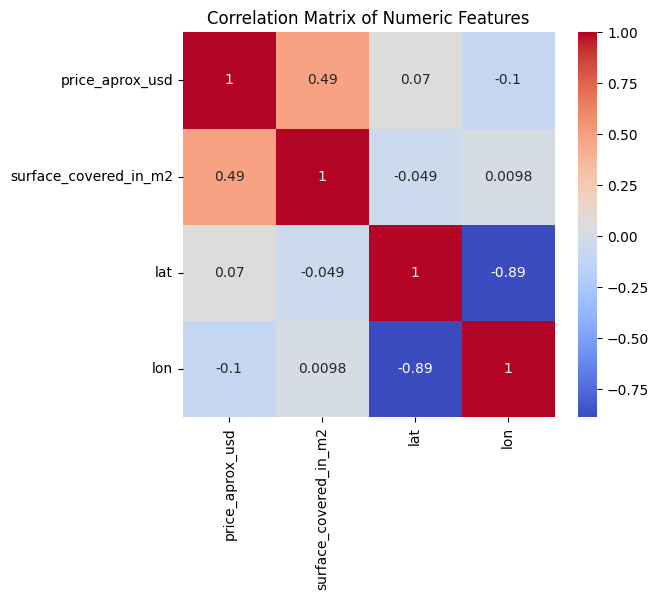

In [19]:
corr_m = df[["price_aprox_usd", "surface_covered_in_m2", "lat", "lon"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_m, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.show()


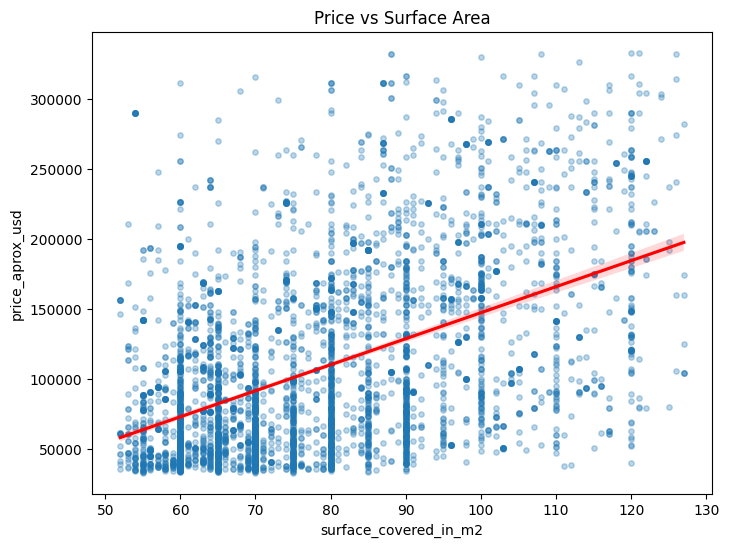

In [20]:
# price vs surface area, most important relationship for this project
plt.figure(figsize=(8,6))
sns.regplot(data=df, x="surface_covered_in_m2", y="price_aprox_usd",
            scatter_kws={"alpha":0.3,"s":15}, line_kws={"color":"red"})
plt.title("Price vs Surface Area")
plt.show()


/tmp/ipykernel_510/630977579.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="borough", x="price_aprox_usd", order=order, palette="crest")


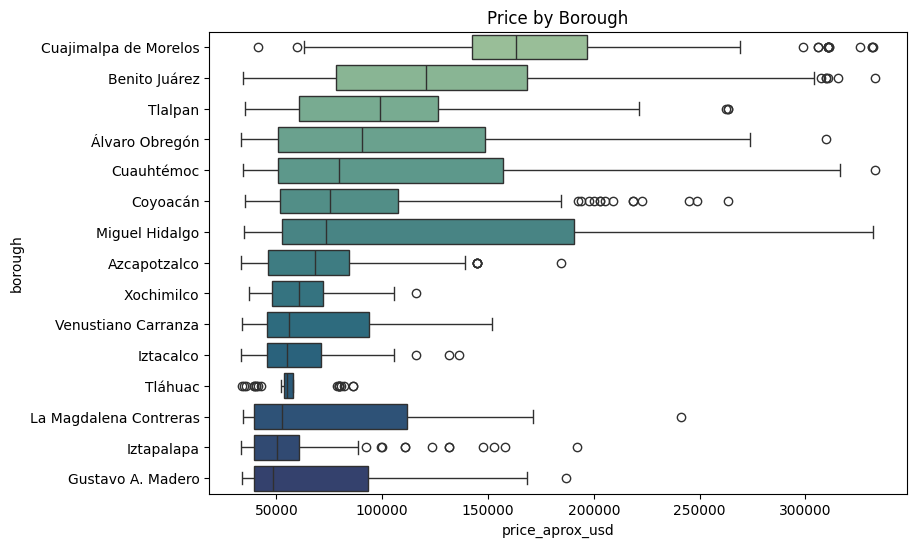

In [21]:
order = df.groupby("borough")["price_aprox_usd"].median().sort_values(ascending=False).index

plt.figure(figsize=(9,6))
sns.boxplot(data=df, y="borough", x="price_aprox_usd", order=order, palette="crest")
plt.title("Price by Borough")
plt.show()


# **Splitting Data into Feature Matrix and target vector**

In [22]:
target = "price_aprox_usd"

y = df[target]
X = df.drop(columns=[target, "lat", "lon"])


In [23]:
y

0       289775.66
1        48822.82
2       232663.51
3       166001.78
4        94022.66
          ...    
4685    247626.47
4686     57955.13
4687     35510.69
4688    156958.30
4689     77141.75
Name: price_aprox_usd, Length: 4690, dtype: float64

In [24]:
X.head()

,surface_covered_in_m2,borough
0,54.0,Miguel Hidalgo
1,100.0,Tlalpan
2,87.0,Miguel Hidalgo
3,100.0,Benito Juárez
4,57.0,Benito Juárez


# **Splitting into Training and Testing set**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# **Baseline**

In [26]:
baseline_pred = [y_train.mean()] * len(y_test)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print(f"This is the Baseline MAE: {round(baseline_mae, 2)}")


This is the Baseline MAE: 54214.48


# **Build Model**

In [27]:
# Separate categorical and numeric columns
categorical_cols = ["borough"]
numeric_cols = ["surface_covered_in_m2"]

# Fit OHE on training categorical columns
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])

# Combine numeric and encoded categorical columns
X_train_final = np.hstack([X_train[numeric_cols].values, X_train_cat])
X_test_final = np.hstack([X_test[numeric_cols].values, X_test_cat])

model = LinearRegression()
model.fit(X_train_final, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# **Evaluate**

In [28]:
y_pred = model.predict(X_test_final)

print("Train R2:", r2_score(y_train, model.predict(X_train_final)))
print("Test R2:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))


Train R2: 0.3257691280645554
Test R2: 0.3261152508352062
Test MAE: 43225.68835478698


In [29]:
# how much better is this than just guessing size, or just guessing borough?
size_only = LinearRegression().fit(X_train[numeric_cols], y_train)
pred = size_only.predict(X_test[numeric_cols])
print("Size only -- R2:", r2_score(y_test, pred), "MAE:", mean_absolute_error(y_test, pred))

loc_only = LinearRegression().fit(X_train_cat, y_train)
pred = loc_only.predict(X_test_cat)
print("Location only -- R2:", r2_score(y_test, pred), "MAE:", mean_absolute_error(y_test, pred))


Size only -- R2: 0.25329050520274476 MAE: 45847.08877976188
Location only -- R2: 0.12807580333103674 MAE: 49115.14457499316


# **Hyper parameter Tuning**

In [30]:
# Linear Regression doesn't really have hyperparams to tune, so trying Ridge instead
# with different alpha (regularization strength) values, same loop pattern as before

alphas = [0.01, 0.1, 1, 5, 10, 50, 100, 200, 500, 1000]

results = []
for a in alphas:
    ridge = Ridge(alpha=a, random_state=42)
    ridge.fit(X_train_final, y_train)
    train_score = r2_score(y_train, ridge.predict(X_train_final))
    test_score = r2_score(y_test, ridge.predict(X_test_final))

    results.append({
        "alpha": a,
        "train_r2": train_score,
        "test_r2": test_score
    })


In [31]:
result_df = pd.DataFrame(results)
result_df

,alpha,train_r2,test_r2
0,0.01,0.325769,0.326116
1,0.10,0.325769,0.326126
2,1.00,0.325759,0.326197
3,5.00,0.325561,0.326186
4,10.00,0.325093,0.325759
5,50.00,0.319005,0.319045
6,100.00,0.311612,0.311293
7,200.00,0.300739,0.300853
8,500.00,0.283045,0.286080
9,1000.00,0.269404,0.276091


In [32]:
# Find the best alpha by test_r2
result_df.loc[result_df["test_r2"].idxmax()]


alpha       1.000000
train_r2    0.325759
test_r2     0.326197
Name: 2, dtype: float64

# **Visualzation for Hyperparameter Tuning**

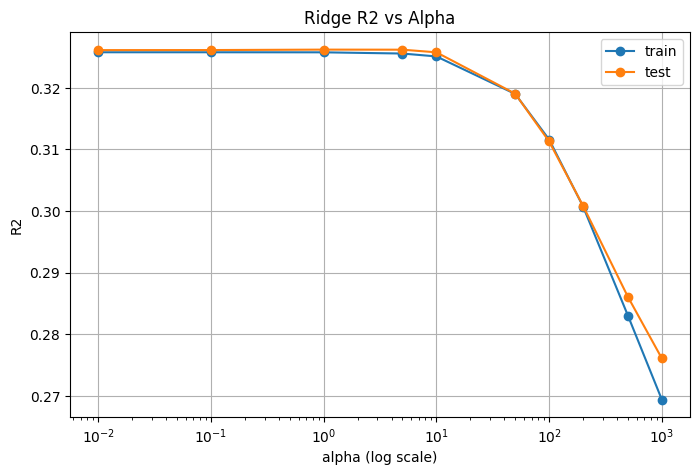

In [33]:
plt.figure(figsize=(8,5))
plt.plot(result_df["alpha"], result_df["train_r2"], marker="o", label="train")
plt.plot(result_df["alpha"], result_df["test_r2"], marker="o", label="test")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("R2")
plt.title("Ridge R2 vs Alpha")
plt.legend()
plt.grid(True)
plt.show()


# **Communicate Results**

In [34]:
cat_features = ohe.get_feature_names_out(categorical_cols)
all_features = list(numeric_cols) + list(cat_features)
coefs = model.coef_

print("Features:", all_features[:3])
print("Coefficients:", coefs[:3])


Features: ['surface_covered_in_m2', 'borough_Azcapotzalco', 'borough_Benito Juárez']
Coefficients: [  1619.20543765 -12469.83640087  30219.07385954]


In [35]:
coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": coefs
}).sort_values(by="coefficient", ascending=False)
coef_df.head(10)


,feature,coefficient
4,borough_Cuajimalpa de Morelos,75384.087895
2,borough_Benito Juárez,30219.073860
10,borough_Miguel Hidalgo,23238.634039
5,borough_Cuauhtémoc,19128.379382
15,borough_Álvaro Obregón,8364.914732
0,surface_covered_in_m2,1619.205438
11,borough_Tlalpan,-3758.884042
13,borough_Venustiano Carranza,-6288.112977
3,borough_Coyoacán,-6942.316659
1,borough_Azcapotzalco,-12469.836401


# **Visualize Feature Coefficients**

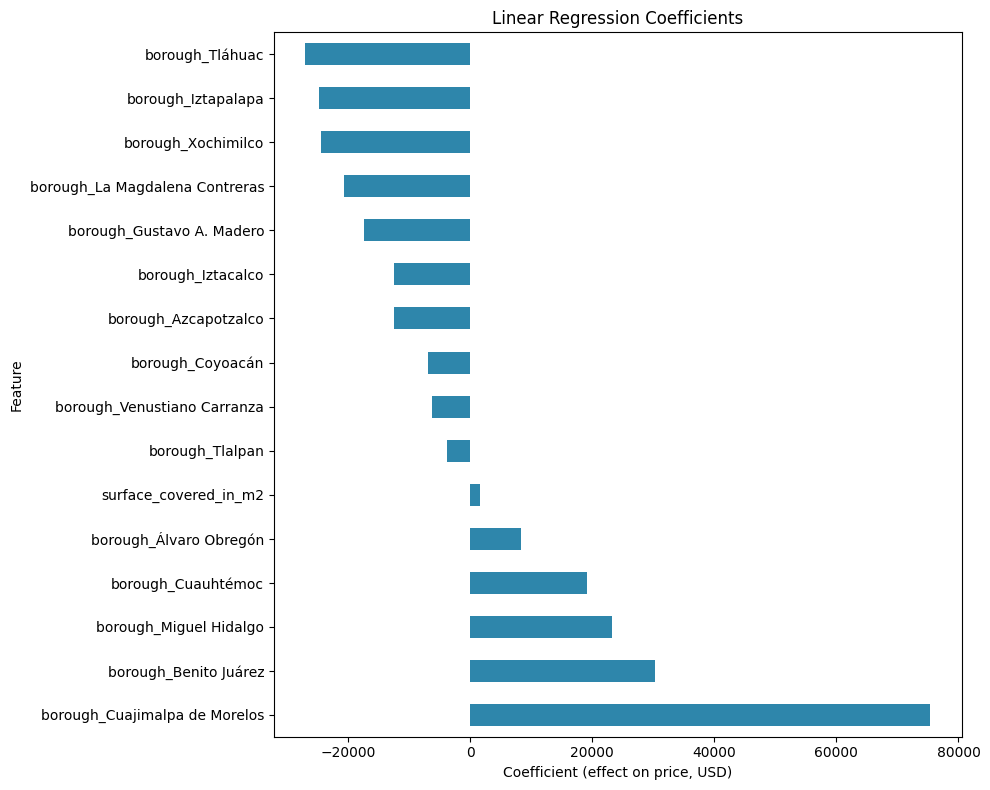

In [36]:
coef_df.set_index("feature")["coefficient"].plot(kind="barh", figsize=(10,8), color="#2E86AB")
plt.xlabel("Coefficient (effect on price, USD)")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients")
plt.tight_layout()
plt.show()


**Takeaway:** size (`surface_covered_in_m2`) and a handful of boroughs (Cuajimalpa de Morelos,
Benito Juárez) have the biggest positive effect on price. Size alone beats location alone on R2,
but the combined model still does best -- confirms both features are pulling their weight, not
just one carrying the whole thing.